# Spaceship Titanic

# 1. Introduccion
---

Este notebook trata sobre la creación de un modelo de clasificación binaria. El objetivo principal es predecir si un pasajero fue Transported a una dimensión alterna después de la colisión de la nave con una anomalía espacio-temporal, basandose en registros recuperados. 

Para abordar este problema, se ha seleccionado el algoritmo CatBoost. Los modelos de Gradient Boosting Decision Trees (GBDT) son conocidos por su alto rendimiento y capacidad para capturar interacciones complejas en los datos sin requerir una escalada previa.

# 2. Librerias
---

In [14]:
# Libraries
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 36)
pd.set_option("display.max_colwidth", 72)
pd.set_option('display.width', 1000)

seed = 42
import numpy as np
np.random.seed(seed)

import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 20})
plt.rcParams["figure.figsize"] = (11, 6.8)

import seaborn as sns
sns.set(font_scale=1)

from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# 3. Investigacion del Dataset
---

In [15]:
# Read training data
train = pd.read_csv("/kaggle/input/u-tad-spaceship-titanic-2025/train.csv")
test = pd.read_csv("/kaggle/input/u-tad-spaceship-titanic-2025/test.csv")
print(train.head(10))
print(train.shape)
print("\n\n")
print(train.info())

  PassengerId HomePlanet CryoSleep  Cabin    Destination   Age    VIP  RoomService  FoodCourt  ShoppingMall     Spa  VRDeck                Name  Transported
0     0001_01     Europa     False  B/0/P    TRAPPIST-1e  39.0  False          0.0        0.0           0.0     0.0     0.0     Maham Ofracculy        False
1     0002_01      Earth     False  F/0/S    TRAPPIST-1e  24.0  False        109.0        9.0          25.0   549.0    44.0        Juanna Vines         True
2     0003_01     Europa     False  A/0/S    TRAPPIST-1e  58.0   True         43.0     3576.0           0.0  6715.0    49.0       Altark Susent        False
3     0003_02     Europa     False  A/0/S    TRAPPIST-1e  33.0  False          0.0     1283.0         371.0  3329.0   193.0        Solam Susent        False
4     0004_01      Earth     False  F/1/S    TRAPPIST-1e  16.0  False        303.0       70.0         151.0   565.0     2.0   Willy Santantines         True
5     0005_01      Earth     False  F/0/P  PSO J318.5-22  

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


## Visualizacion de valores nulos

Se delega la imputación y el tratamiento de los valores nulos a CatBoost.

Para features categóricas, CatBoost asigna automáticamente los valores nulos a una categoría implícita separada o los gestiona mediante el esquema de codificación de features propio del algoritmo.

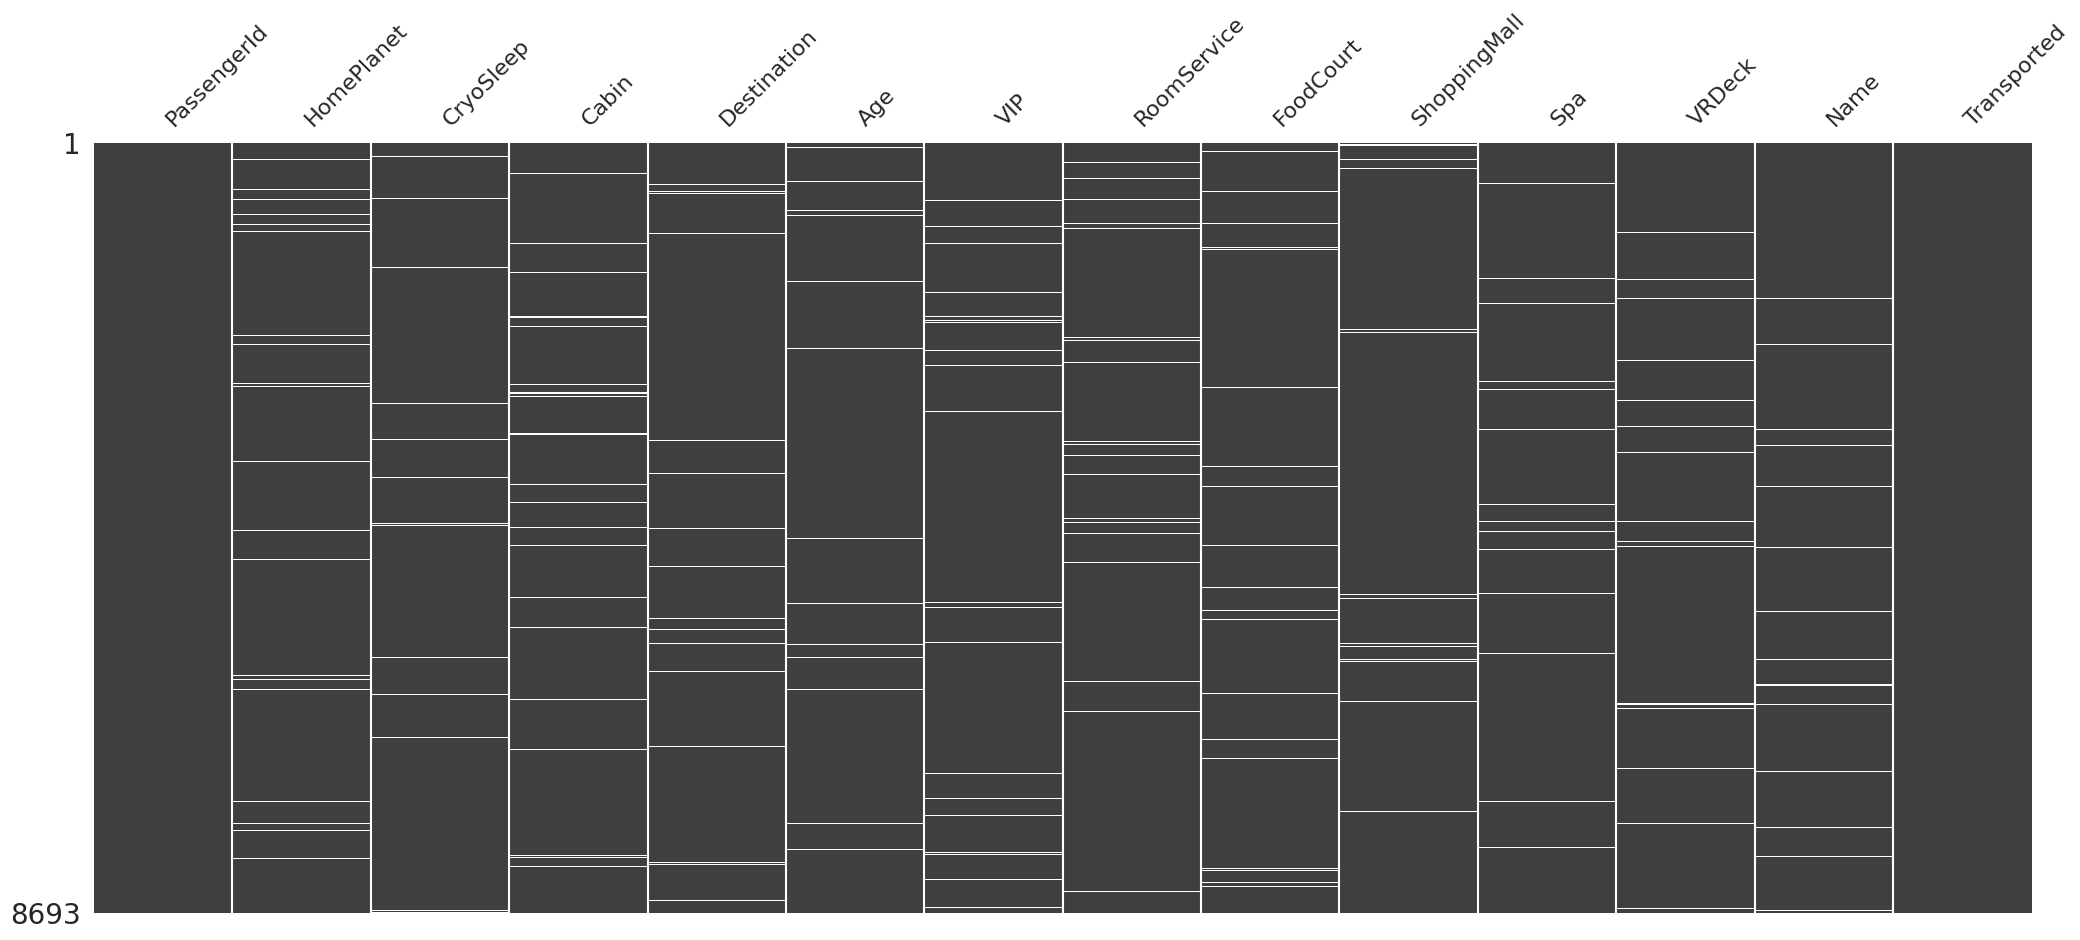

In [16]:
import missingno as msno
msno.matrix(train, sparkline=False);

# 4. Feature Engineering
---

#### 4.1 Descomposición de Identificadores Jerárquicos

Se descompone la información contenida en los identificadores originales para obtener nuevos features:

* **`PassengerId`**: Se separa en **`Group`** (identificador de grupo de viaje) y **`GroupNum`** (número del pasajero dentro de dicho grupo). El tamaño del grupo (`GroupSize`) se calcula posteriormente.
* **`Cabin`**: Se descompone en tres features categóricas: **`Deck`**, **`CabinNum`** (convertida a numérica) y **`Side`** (`P` o `S`), para inferir la ubicación y el nivel de lujo.

#### 4.2 Transformación de Tipos de Dato para CatBoost

Las features de tipo booleano (`CryoSleep`, `VIP`) se convierten explícitamente a tipo string (`str`). (Realmente no haria falta con catboost)

#### 4.3 Creación de Features de Gasto

Las cinco columnas que registran el gasto en servicios a bordo (`RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck`) se resumen y se transforman para capturar patrones de comportamiento del pasajero:

* **`TotalSpend`**: Suma agregada de todos los servicios. Esta feature es util para detectar el nivel socioeconómico y el estatus.
* **`NoSpend` / `HasSpend`**: Indicadores binarios que identifican si el pasajero tiene gasto total cero. 
* **`AvgSpendPerCategory`**: Gasto promedio para normalizar la escala de gasto.

#### 4.4 Features Demográficas y de Comportamiento

* **`GroupSize`**: Se calcula el número de pasajeros que viajan en el mismo `Group`.
* **`AgeGroup`**: La edad continua (`Age`) se discretiza en categorías ordinales (Child, Teen, Adult, etc.). Esto permite al modelo capturar patrones no lineales asociados a las etapas de la vida sin necesidad de cortes complejos en el arbol.
* **`Name`**: Se descompone para extraer los componentes (`FirstName`, `LastName`). El `LastName` puede ser útil para inferir lazos familiares no cubiertos por el `Group`, pero el `FirstName` se elimina debido a su alta cardinalidad.

#### 4.5 Exclusión Final

Las features originales de identificación (`PassengerId`, `Name`, `Cabin`) se eliminan del conjunto de entrenamiento tras la extracción de su información.

In [17]:
def feature_engineer(df):
    df = df.copy()
    
    # PassengerId: Group and Group number
    df[['Group', 'GroupNum']] = df['PassengerId'].str.split('_', expand=True)
    df['Group'] = df['Group'].astype(int)
    df['GroupNum'] = df['GroupNum'].astype(int)

    #CryoSleep: Convertir a string para CatBoost.
    if 'CryoSleep' in df.columns:
        df['CryoSleep'] = df['CryoSleep'].astype(str)
    
    # Cabin: Deck/Num/Side
    df[['Deck', 'CabinNum', 'Side']] = df['Cabin'].str.split('/', expand=True)
    df['CabinNum'] = pd.to_numeric(df['CabinNum'], errors='coerce')

    #VIP: Convertir a string para CatBoost
    if 'VIP' in df.columns:
        df['VIP'] = df['VIP'].astype(str)
    
    # Name: 
    if 'Name' in df.columns:
        df[['FirstName', 'LastName']] = df['Name'].str.split(' ', expand=True)
    
    # Spending features
    spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    df['TotalSpend'] = df[spend_cols].sum(axis=1)
    df['NoSpend'] = (df['TotalSpend'] == 0).astype(int)
    df['HasSpend'] = (df['TotalSpend'] > 0).astype(int)
    
    # Average spending 
    df['AvgSpendPerCategory'] = df['TotalSpend'] / 5
    
    # Group size 
    group_sizes = df.groupby('Group').size()
    df['GroupSize'] = df['Group'].map(group_sizes)
    
    # Age groups
    df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 50, 100], 
                            labels=['Child', 'Teen', 'Adult', 'MiddleAge', 'Senior'])
    
    # Drop columnas originales
    cols_to_drop = ['PassengerId', 'Name', 'Cabin']
    if 'FirstName' in df.columns:
        cols_to_drop.append('FirstName')  
    
    df = df.drop([col for col in cols_to_drop if col in df.columns], axis=1)
    
    return df

In [18]:
#Aplicamos el feature engineering
train_fe = feature_engineer(train)
test_fe = feature_engineer(test)
print("\nFeatures despues del engeenering:")
print(train_fe.head())
print("\nTipos de datos:")
print(train_fe.dtypes)
print(train_fe.nunique())


Features despues del engeenering:
  HomePlanet CryoSleep  Destination   Age    VIP  RoomService  FoodCourt  ShoppingMall     Spa  VRDeck  Transported  Group  GroupNum Deck  CabinNum Side     LastName  TotalSpend  NoSpend  HasSpend  AvgSpendPerCategory  GroupSize   AgeGroup
0     Europa     False  TRAPPIST-1e  39.0  False          0.0        0.0           0.0     0.0     0.0        False      1         1    B       0.0    P    Ofracculy         0.0        1         0                  0.0          1  MiddleAge
1      Earth     False  TRAPPIST-1e  24.0  False        109.0        9.0          25.0   549.0    44.0         True      2         1    F       0.0    S        Vines       736.0        0         1                147.2          1      Adult
2     Europa     False  TRAPPIST-1e  58.0   True         43.0     3576.0           0.0  6715.0    49.0        False      3         1    A       0.0    S       Susent     10383.0        0         1               2076.6          2     Senior
3    

# 5. Preparación de los datos para catboost
---

Se define el set de features categóricas en base a lo observado anteriormente y las nuevas features creadas

De las nuevas columnas, incluimos:

* **`GroupNum`**: Representa la posición dentro del grupo (1, 2, 3...). Al ser de muy baja cardinalidad, debe ser tratada como categórica u ordinal para evitar que el modelo asuma una relación lineal.
* **`NoSpend`**, **`HasSpend`**: Flags binarias
* **`GroupSize`**: El tamaño del grupo es un valor discreto y de baja cardinalidad. Se trata como categórico ya que el impacto de un grupo de tamaño 7 puede no ser linealmente diferente al de un grupo de tamaño 8.
* **`Deck'**, **`Side`**.
* **`AgeGroup'**.
* **`LastName`**: Se incluye como categórica para permitir que CatBoost aplique su codificación buscando patrones familiares o de grupo en la probabilidad de transporte.

In [19]:
X = train_fe.drop('Transported', axis=1)
y = train_fe['Transported'].astype(int)
X_test = test_fe.copy()

categorical_features = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP','Deck', 'Side', 'LastName', 'AgeGroup', 'GroupNum', 'HasSpend', 'NoSpend', 'GroupSize']
categorical_features = [col for col in categorical_features if col in X.columns]
print("\nCategorical features:", categorical_features)
print("Shape X:", X.shape)
print("Shape y:", y.shape)


Categorical features: ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side', 'LastName', 'AgeGroup', 'GroupNum', 'HasSpend', 'NoSpend', 'GroupSize']
Shape X: (8693, 22)
Shape y: (8693,)


## Split data

In [20]:
#Split data for validation
X_train, X_val, y_train, y_val = train_test_split(
X, y, test_size=0.2, random_state=seed, stratify=y
)
print("\nTrain set:", X_train.shape)
print("Validation set:", X_val.shape)


Train set: (6954, 22)
Validation set: (1739, 22)


## Imputación de valores nulos en categoricas

### (Error `CatBoostError: bad object for id: nan`)

Aunque CatBoost posee mecanismos internos para manejar valores nulos en features categóricas, estos mecanismos tienen un **requisito estricto de tipo de dato** que falló en mi pipeline actual.

**Incidencia Detectada:** Al crear el `Pool`, CatBoost lanzo un error porque una o más features categóricas especificadas en `cat_features` contienen valores nulos (`NaN`) que fueron cargados o generados como tipo **float**, y no como tipo **string**.

**Razón del Error:** El valor `float('nan')` no es un tipo de dato válido para el esquema de codificación de CatBoost. El algoritmo requiere que todos los valores, incluidos los nulos, se presenten como tipos que puedan ser mapeados (cadenas o enteros).

Para resolver este conflicto de tipos se aplica una imputación explícita:

1.  **Conversión:** Se fuerza la conversión de la columna a `str`. Esto convierte cualquier `float('nan')` en la cadena literal `'nan'`.
2.  **Imputación Controlada:** Se utiliza `.replace('nan', 'Missing')` para sustituir la cadena literal `'nan'` por el string **`'Missing'`**.

In [21]:

for col in categorical_features:
    X_train[col] = X_train[col].astype('object').fillna('Missing').astype(str)
    test_fe[col] = test_fe[col].astype('object').fillna('Missing').astype(str)
    
    X_val[col] = X_val[col].astype('object').fillna('Missing').astype(str)

train_pool = Pool(X_train,y_train,cat_features=categorical_features)
val_pool = Pool(X_val,y_val,cat_features=categorical_features)

#CatBoost Classifier
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function='Logloss',
    eval_metric='Accuracy',
    random_seed=seed,
    early_stopping_rounds=50,
    verbose=100,
    task_type='CPU',
    l2_leaf_reg=3,
    border_count=128,
    bagging_temperature=1
)

print("\n" + "="*50)
print("Training CatBoost Model")
print("="*50)
model.fit(train_pool,eval_set=val_pool,use_best_model=True,plot=False)


Training CatBoost Model


/tmp/ipykernel_47/515060330.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train[col] = X_train[col].astype('object').fillna('Missing').astype(str)
/tmp/ipykernel_47/515060330.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_fe[col] = test_fe[col].astype('object').fillna('Missing').astype(str)
/tmp/ipykernel_47/515060330.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.se

0:	learn: 0.7450388	test: 0.7360552	best: 0.7360552 (0)	total: 94.6ms	remaining: 1m 34s
100:	learn: 0.8324705	test: 0.7975848	best: 0.7981599 (88)	total: 3.09s	remaining: 27.5s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8021851639
bestIteration = 115

Shrink model to first 116 iterations.


In [22]:
y_pred = model.predict(test_fe)

# placeholder predictions
#y_pred = 0

In [23]:
predictions_Boolean = (y_pred > 0.5) # here we are using a decision threshold of p=0.5

In [24]:
# do not modify this code
submission = pd.read_csv("/kaggle/input/u-tad-spaceship-titanic-2025/sample_submission.csv")
submission["Transported"] = predictions_Boolean
submission.to_csv('submission.csv',index=False)

In [25]:
submission.head()

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,False


# 6. Resultados
---

### 6.1 Resultados del Modelo Baseline

| Metrica | Validation Set | Test Set |
| :--- | :--- | :--- |
| **Accuracy** | 0.79758 | 0.79752 |
| **Mejor iteracion** | 47 | N/A |

Hiperparametros:
{
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function='Logloss',
    eval_metric='Accuracy',
    random_seed=seed,
    early_stopping_rounds=50,
    verbose=100,
    task_type='CPU',
    l2_leaf_reg=3,
    border_count=128,
    bagging_temperature=1
}

### 6.2 Resultados del Modelo Optimizado

Implementacion de feature engeenering creando nuevas caracteristicas mecionadas anteriormente.

| Metrica | Validation Set | Test Set |
| :--- | :--- | :--- |
| **Accuracy** | 0.80218 | 0.80500 |
| **Mejor iteracion** | 115 | N/A |

Hiperparametros:
{
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function='Logloss',
    eval_metric='Accuracy',
    random_seed=seed,
    early_stopping_rounds=50,
    verbose=100,
    task_type='CPU',
    l2_leaf_reg=3,
    border_count=128,
    bagging_temperature=1
}

La incorporación de las nuevas features influyo en el resultado tanto del Validation Set, pero sobre todo del Test Set. Las iteraciones incrementaron x3. 

### 6.3 Resultados del Modelo Optimizado anadiendo mas columnas

##### Para esta iteracion del modelo se anadieron mas columnas a las ensenadas en este notebook:
- df['Log_Total_Spend'] = np.log1p(df['TotalSpend']): Transformación logarítmica para normalizar la distribución sesgada de los gastos
- df['Cryo_Spend_Anomaly'] = ((df['CryoSleep'] == 'True') & (df['TotalSpend'] > 0)).astype(int): Un flag binario que detecta inconsistencias en el dataset: pasajeros marcados como en criosueño (CryoSleep=True) pero que registran gastos en los servicios de la nave (TotalSpend > 0)

| Metrica | Validation Set | Test Set |
| :--- | :--- | :--- |
| **Accuracy** | 0.80563 | 0.80430|
| **Mejor iteracion** | 136 | N/A |

Hiperparametros:
{
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function='Logloss',
    eval_metric='Accuracy',
    random_seed=seed,
    early_stopping_rounds=50,
    verbose=100,
    task_type='CPU',
    l2_leaf_reg=3,
    border_count=128,
    bagging_temperature=1
}

Con los mismos hiperparámetros mejoró el validation set pero empeoró con el test, manteniendo las iteraciones similares. Se propusieron nuevos parámetros con más iteraciones para intentar combatir el sobreajuste

##### Probando otros distintos:

Hiperparametros:
{
    iterations=5000,
    learning_rate=0.01,
    depth=6,
    loss_function='Logloss',
    eval_metric='Accuracy',
    random_seed=seed,
    early_stopping_rounds=50,
    verbose=100,
    task_type='CPU',
    l2_leaf_reg=3,
    border_count=128,
    bagging_temperature=1
}

| Metrica | Validation Set | Test Set |
| :--- | :--- | :--- |
| **Accuracy** | 0.79355 | 0.79892|
| **Mejor iteracion** | 361 | N/A |

Empeoro tanto en el Validation como en el Test Set. Se descartaron estas columnas y se volvió a los parámetros iniciales.





# 7. Conclusión
---

- #### Buen modelo: Trabajar con CatBoost fue buena decisión. Desde el modelo baseline se obtuvieron buenos resultaods. 

- #### Feature engeenering: La creación de nuevas columnas fue lo que impulsó la mejora del modelo, mientras que el tuning de hipermarámetros no trajo consigo resultados. 

- #### Pasos a seguir: Realizar un análisis de los falsos positivos y negativos sobre el conjunto de validación para detectar que tipo de pasajeros está prediciendo mal. Esto nos aportaría nuevas ideas para nuevas columnas. Además, sería razonable buscar formas de optimizar los hiperparámetros mediante algoritmos. 



# 8. Referencias
---

Para la realización de este notebook he consultado los materiales aportados por el profesor, he preguntado a compañeros de clase sobre sus experiencias con este modelo y otros y he revisado tutoriales en internet: 
- https://www.kaggle.com/code/mitribunskiy/tutorial-catboost-overview
